В задании используется база курса акций Лукойла.

1. Обучите простую полносвязную сеть для прогнозирования временного ряда (только close) и визуализируйте результат.

2. Обучите такую же архитектуру сети на прогнозирование на 10 шагов вперёд прямым способом и визуализируйте результат.

3. Постройте графики сравнения предсказания с оригинальным сигналом по всем 10 шагам предсказания (10 графиков на разных отдельных осях).

4. Сделайте те же задания с другой сетью, которая будет использовать Conv1D или LSTM слои.


## Подготовка данных

Загрузка библиотек

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import MinMaxScaler

plt.style.use('ggplot')

Загрузка базы

In [ ]:
import gdown

gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l11/16_17.csv', None, quiet=True)
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l11/18_19.csv', None, quiet=True)

data16 = pd.read_csv('16_17.csv', sep=';').drop(columns=['DATE','TIME'])
data18 = pd.read_csv('18_19.csv', sep=';').drop(columns=['DATE','TIME'])

data = pd.concat([data16, data18]).to_numpy()

In [ ]:
# Индексы признаков (X) и целевой переменной (Y)
chn_x = [0,1,2,3,4]
chn_y = [3]

In [ ]:
# Нормализация входных и выходных данных
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

x_data = x_scaler.fit_transform(data[:, chn_x])
y_data = y_scaler.fit_transform(data[:, chn_y])

In [ ]:
SEQ_LEN = 300 # Длина входной последовательности
TEST_LEN = 30000

# Разделение на train/test с сохранением временного порядка
train_size = len(x_data) - TEST_LEN

x_train = x_data[:train_size]
x_test = x_data[train_size - SEQ_LEN:]

y_train = y_data[:train_size]
y_test = y_data[train_size - SEQ_LEN:]

 Dataset для 1-шагового прогноза

In [ ]:
# Формирование скользящих окон для временного ряда
class TSData(Dataset):
    def __init__(self, x, y, seq_len):
        self.x = x
        self.y = y
        self.seq_len = seq_len

    def __len__(self):
      # количество доступных окон
        return len(self.x) - self.seq_len

    def __getitem__(self, i):
      # вход: последовательность длиной SEQ_LEN
        X = self.x[i:i+self.seq_len]
        # целевая переменная — следующий шаг после окна
        Y = self.y[i+self.seq_len]
        return torch.tensor(X, dtype=torch.float32), torch.tensor(Y, dtype=torch.float32)

In [ ]:
BATCH_SIZE = 20

train_ds = TSData(x_train, y_train, SEQ_LEN)
test_ds = TSData(x_test, y_test, SEQ_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

Dense модель (1 шаг)

In [ ]:
class DenseModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(SEQ_LEN * len(chn_x), 150),
            nn.ReLU(),
            nn.Linear(150, 1)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model1 = DenseModel().to(device)
# Оптимизатор и функция потерь
opt = torch.optim.Adam(model1.parameters(), lr=1e-4)
loss_fn = nn.MSELoss()

Обучение модели

In [ ]:
for epoch in range(10):
    model1.train()
    for x,y in train_loader:
        x,y = x.to(device), y.to(device)

        pred = model1(x)
        loss = loss_fn(pred, y)

        opt.zero_grad()
        loss.backward()
        opt.step()

Оценка модели (1 шаг)

In [ ]:
model1.eval()

preds, trues = [], []
# Вычисление предсказаний на тесте
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        p = model1(x).cpu().numpy()

        preds.append(p)
        trues.append(y.numpy())

preds = np.vstack(preds)
trues = np.vstack(trues)

In [ ]:
# Возврат к исходному масштабу цен
preds_inv = y_scaler.inverse_transform(preds)
trues_inv = y_scaler.inverse_transform(trues)

Визуализация

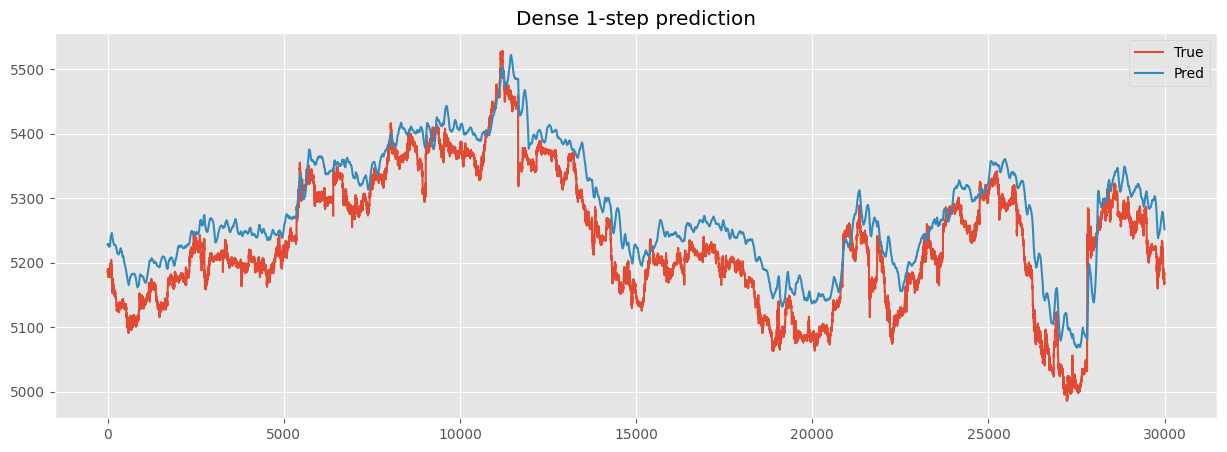

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(trues_inv, label="True")
plt.plot(preds_inv, label="Pred")
plt.title("Dense 1-step prediction")
plt.legend()
plt.show()

Dataset для 10 шагов

In [ ]:
# Dataset для прямого многошагового прогноза (10 точек вперёд)
class TS10(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __len__(self):
        return len(self.x) - SEQ_LEN - 10

    def __getitem__(self, i):
        X = self.x[i:i+SEQ_LEN]

        Y = self.y[i+SEQ_LEN:i+SEQ_LEN+10]
        Y = Y.reshape(-1)   # <<< ВОТ ЭТО ИСПРАВЛЕНИЕ

        return torch.tensor(X, dtype=torch.float32), torch.tensor(Y, dtype=torch.float32)

In [ ]:
train10 = TS10(x_train, y_train)
train10_loader = DataLoader(train10, batch_size=32, shuffle=False)

Dense модель (10 шагов)

In [ ]:
# Полносвязная сеть для многошагового прогноза
class Dense10(nn.Module):
    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(SEQ_LEN * len(chn_x), 200),
            nn.ReLU(),
            nn.Linear(200, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

Обучение Dense10 (10 шагов вперёд)

In [ ]:
model2 = Dense10().to(device)
opt = torch.optim.Adam(model2.parameters(), lr=1e-4)
loss_fn = nn.MSELoss()

for epoch in range(10):
    for x,y in train10_loader:
        x,y = x.to(device), y.to(device)
        # прямой проход (предсказание 10 значений сразу)
        pred = model2(x)
        # вычисление ошибки между прогнозом и реальными значениями
        loss = loss_fn(pred, y)

        opt.zero_grad()
        loss.backward()
        opt.step()

Оценка Dense10 модели (10 шагов)

In [ ]:
model2.eval()

preds, trues = [], []

with torch.no_grad():
    for x,y in train10_loader:
        x = x.to(device)
        p = model2(x).cpu().numpy()

        preds.append(p)
        trues.append(y.numpy())

preds = np.vstack(preds)
trues = np.vstack(trues)

Визуализация

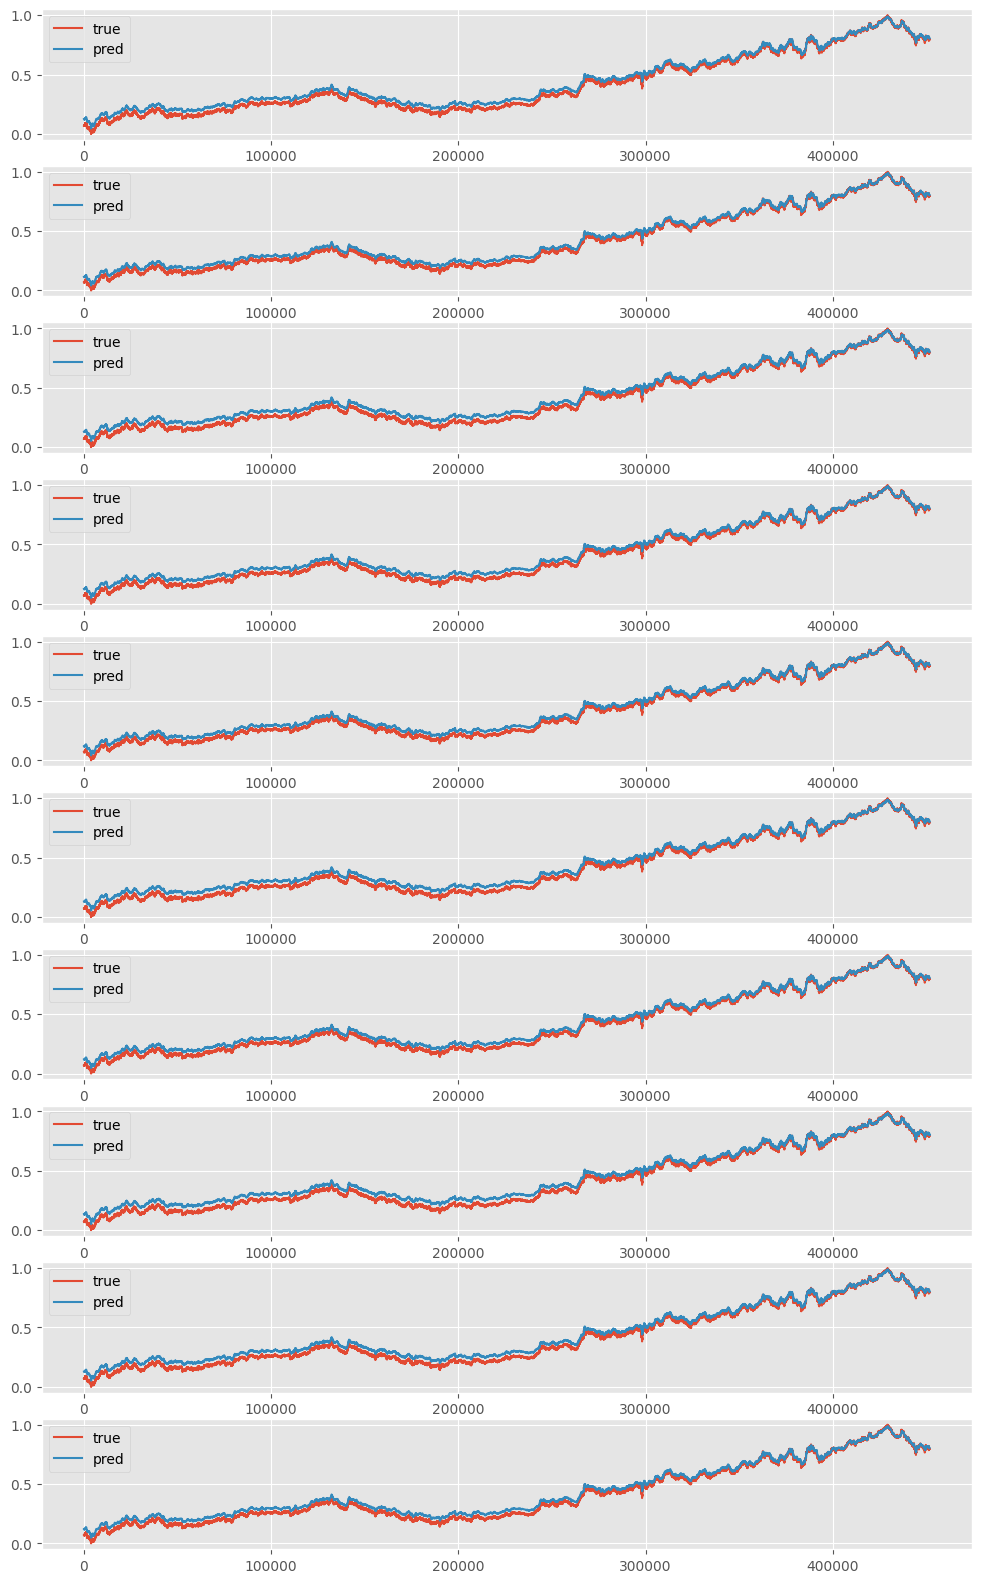

In [ ]:
fig, ax = plt.subplots(10, 1, figsize=(12, 20))

for i in range(10):
    ax[i].plot(trues[:, i], label="true")
    ax[i].plot(preds[:, i], label="pred")
    ax[i].legend()

plt.show()

Conv1D + LSTM (1 шаг)

In [ ]:
class ConvModel(nn.Module):
    def __init__(self):
        super().__init__()
        # свёртка по времени
        self.conv = nn.Conv1d(len(chn_x), 64, kernel_size=3)
        # рекуррентная обработка признаков
        self.lstm = nn.LSTM(64, 64, batch_first=True)

        self.fc = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        x = x.permute(0,2,1)  # (batch, features, time)
        # обратно в формат LSTM
        x = self.conv(x)
        x = x.permute(0,2,1)

        x,_ = self.lstm(x)
        x = x[:,-1,:]

        return self.fc(x)

Обучение модели Conv1D + LSTM (1 шаг)

In [ ]:
model3 = ConvModel().to(device)
opt = torch.optim.Adam(model3.parameters(), lr=1e-4)
loss_fn = nn.MSELoss()

for epoch in range(10):
    model3.train()
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        pred = model3(x)
        loss = loss_fn(pred, y)

        opt.zero_grad()
        loss.backward()
        opt.step()


Визуализация

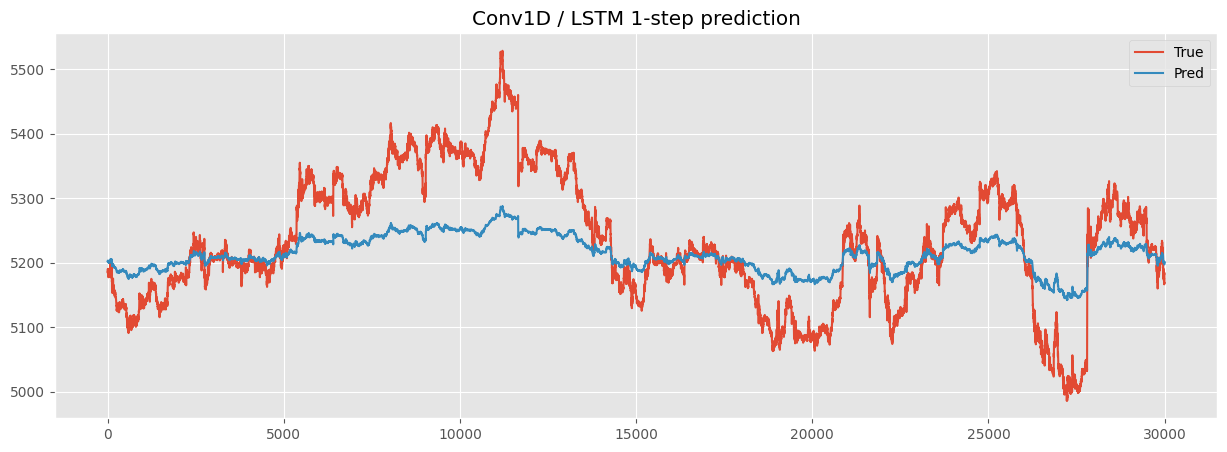

In [ ]:
model3.eval()

preds, trues = [], []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        p = model3(x).cpu().numpy()

        preds.append(p)
        trues.append(y.numpy())

preds = np.vstack(preds)
trues = np.vstack(trues)

preds_inv = y_scaler.inverse_transform(preds)
trues_inv = y_scaler.inverse_transform(trues)

plt.figure(figsize=(15,5))
plt.plot(trues_inv, label="True")
plt.plot(preds_inv, label="Pred")
plt.title("Conv1D / LSTM 1-step prediction")
plt.legend()
plt.show()

Dataset для прогноза на 10 шагов

In [ ]:
class TS10(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __len__(self):
        return len(self.x) - SEQ_LEN - 10

    def __getitem__(self, i):
        X = self.x[i:i+SEQ_LEN]
        Y = self.y[i+SEQ_LEN:i+SEQ_LEN+10]

        Y = Y.reshape(-1)  # (10,)

        return torch.tensor(X, dtype=torch.float32), torch.tensor(Y, dtype=torch.float32)

In [ ]:
train10_ds = TS10(x_train, y_train)
train10_loader = DataLoader(train10_ds, batch_size=32, shuffle=False)

Модель LSTM(10 шагов)

In [ ]:
# LSTM для прямого многошагового прогноза
class LSTM10(nn.Module):
    def __init__(self):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=len(chn_x),
            hidden_size=64,
            batch_first=True
        )

        self.fc = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 10)# 10 будущих шагов
        )

    def forward(self, x):
        x, _ = self.lstm(x)
        x = x[:, -1, :]
        return self.fc(x)

Обучение LSTM10 (10 шагов вперёд)

In [ ]:
model_lstm = LSTM10().to(device)

opt = torch.optim.Adam(model_lstm.parameters(), lr=1e-4)
loss_fn = nn.MSELoss()

for epoch in range(10):
    model_lstm.train()

    for x, y in train10_loader:
        x, y = x.to(device), y.to(device)

        pred = model_lstm(x)
        loss = loss_fn(pred, y)

        opt.zero_grad()
        loss.backward()
        opt.step()

Оценка LSTM модели

In [ ]:
model_lstm.eval()

preds, trues = [], []

with torch.no_grad():
    for x, y in train10_loader:
        x = x.to(device)
        # прогноз 10 будущих значений
        p = model_lstm(x).cpu().numpy()

        preds.append(p)
        trues.append(y.numpy())
# Объединение батчей в единые массив
preds = np.vstack(preds)
trues = np.vstack(trues)

Визуализация

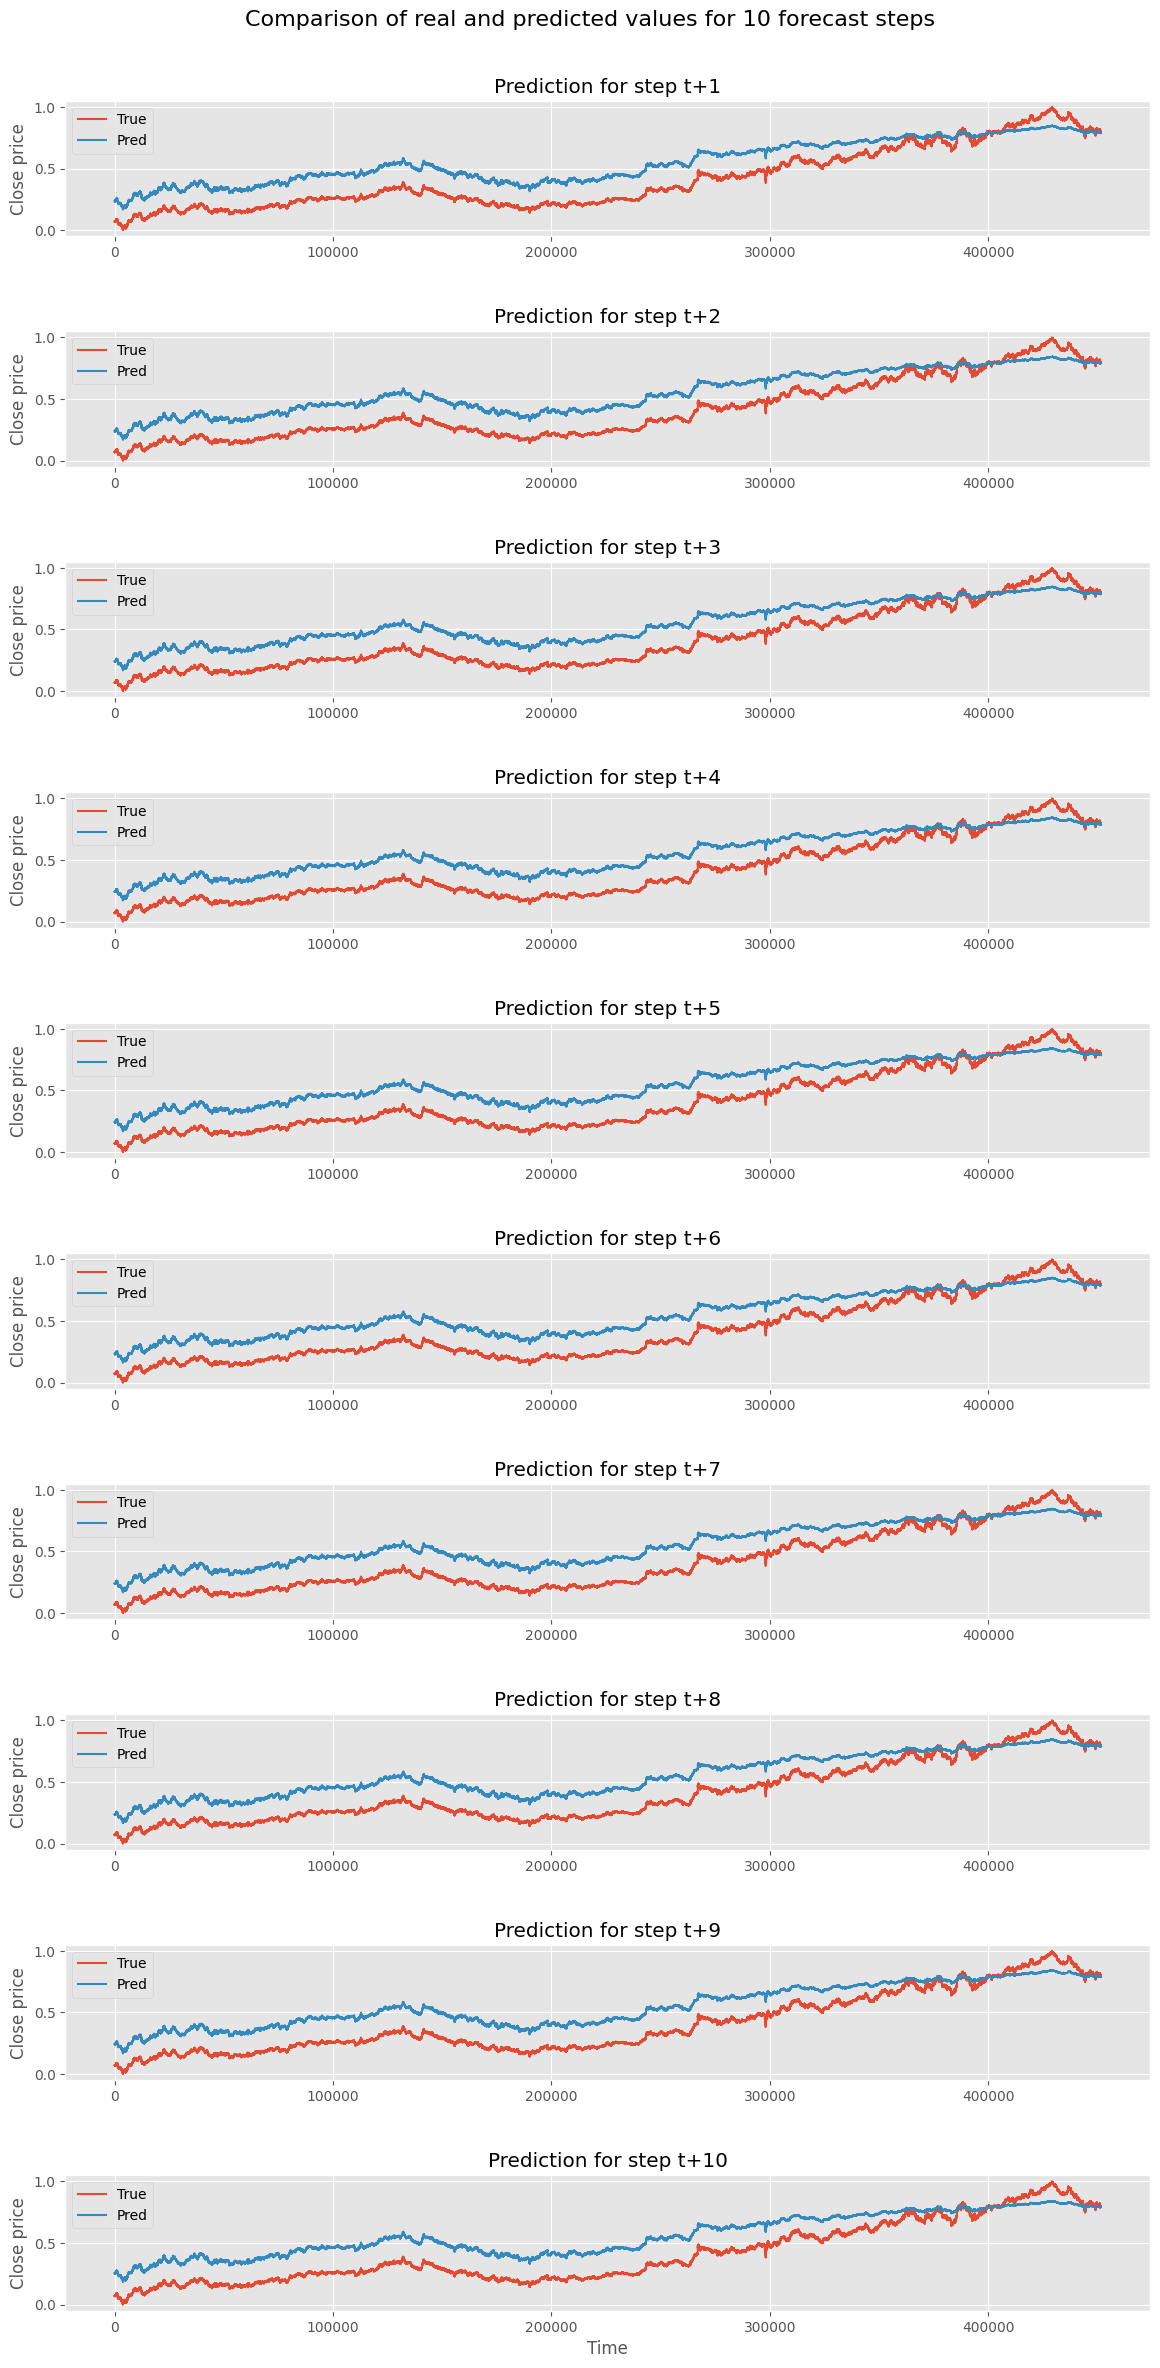

In [ ]:
fig, ax = plt.subplots(10, 1, figsize=(14, 26))

for i in range(10):
    ax[i].plot(trues[:, i], label="True")
    ax[i].plot(preds[:, i], label="Pred")

    ax[i].set_title(f'Prediction for step t+{i+1}')
    ax[i].set_ylabel('Close price')

    # подпись X только снизу
    if i == 9:
        ax[i].set_xlabel('Time')

    ax[i].legend()
    ax[i].grid(True)

plt.suptitle(
    'Comparison of real and predicted values for 10 forecast steps',
    fontsize=16,
    y=0.995
)

# увеличиваем расстояние между графиками
plt.subplots_adjust(hspace=0.7, top=0.96)

plt.show()